In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score

In [2]:
def evaluate_experiments(plots_filter, threshold_05=False, results_folder="results"):
    """
    Evaluates, prints metrics, and plots curves for selected ML experiments.
    Rankings are automatically sorted by Total Cost (ascending).
    """
    # 1. Define operational business costs globally
    COST_FN = 15.0  # Missing a crisis (False Negative) is 5x worse
    COST_FP = 1.0  # Raising a false alarm (False Positive) costs 1
    COST_TP = 0.0 
    COST_TN = 0.0

    experiments_map = {
        # --- SOLO GROUPS ---
        "Benchmark": "benchmark_persistence",
        "Baseline (Signals)": "only_baseline",
        "Only Historical": "only_historical",
        "Only Embeddings": "only_embedding",
        "Only INFORM Index": "only_inform",
        "Only Severity Index": "only_severity",

        "Baseline (Signals) BEST": "only_baseline_best",
        "Only Historical BEST": "only_historical_best",
        "Only Embeddings BEST": "only_embedding_best",
        "Only INFORM Index BEST": "only_inform_best",
        "Only Severity Index BEST": "only_severity_best",

        # --- COMBINED GROUPS ---
        "Baseline + Historical": "baseline_historical",
        "Baseline + Embeddings": "baseline_embedding",
        "Baseline + INFORM": "baseline_inform",
        "Historical + Embeddings": "historical_embedding",
        "Historical + INFORM": "historical_inform",
        "Embeddings + INFORM": "embedding_inform",
        "Baseline + Historical + Embeddings": "baseline_historical_embedding",
        "Baseline + Historical + INFORM": "baseline_historical_inform",
        "Baseline + Embeddings + INFORM": "baseline_embedding_inform",
        "Historical + Embeddings + INFORM": "historical_embedding_inform",
        "Baseline + Historical + Embeddings + INFORM": "baseline_historical_embedding_inform",
        "Baseline + Severity": "baseline_severity",
        "Historical + Severity": "historical_severity",
        "Embedding + Severity": "embedding_severity",
        "INFORM + Severity": "inform_severity",
        "Baseline + Historical + Severity": "baseline_historical_severity",
        "Baseline + Embeddings + Severity": "baseline_embedding_severity",
        "Baseline + INFORM + Severity": "baseline_inform_severity",
        "Historical + Embeddings + Severity": "historical_embedding_severity",
        "Historical + INFORM + Severity": "historical_inform_severity",
        "Embeddings + INFORM + Severity": "embedding_inform_severity",
        "Baseline + Historical + Embeddings + Severity": "baseline_historical_embedding_severity",
        "Baseline + Historical + INFORM + Severity": "baseline_historical_inform_severity",
        "Baseline + Embeddings + INFORM + Severity": "baseline_embedding_inform_severity",
        "Historical + Embeddings + INFORM + Severity": "historical_embedding_inform_severity",
        "Baseline + Historical + Embeddings + INFORM + Severity": "all_features",

        "Baseline + Historical BEST": "baseline_historical_best",
        "Baseline + Embeddings BEST": "baseline_embedding_best",
        "Baseline + INFORM BEST": "baseline_inform_best",
        "Historical + Embeddings BEST": "historical_embedding_best",
        "Historical + INFORM BEST": "historical_inform_best",
        "Embeddings + INFORM BEST": "embedding_inform_best",
        "Baseline + Historical + Embeddings BEST": "baseline_historical_embedding_best",
        "Baseline + Historical + INFORM BEST": "baseline_historical_inform_best",
        "Baseline + Embeddings + INFORM BEST": "baseline_embedding_inform_best",
        "Historical + Embeddings + INFORM BEST": "historical_embedding_inform_best",
        "Baseline + Historical + Embeddings + INFORM BEST": "baseline_historical_embedding_inform_best",

        "Baseline + Severity BEST": "baseline_severity_best",
        "Historical + Severity BEST": "historical_severity_best",
        "Embedding + Severity BEST": "embedding_severity_best",
        "INFORM + Severity BEST": "inform_severity_best",
        "Baseline + Historical + Severity BEST": "baseline_historical_severity_best",
        "Baseline + Embeddings + Severity BEST": "baseline_embedding_severity_best",
        "Baseline + INFORM + Severity BEST": "baseline_inform_severity_best",
        "Historical + Embeddings + Severity BEST": "historical_embedding_severity_best",
        "Historical + INFORM + Severity BEST": "historical_inform_severity_best",
        "Embeddings + INFORM + Severity BEST": "embedding_inform_severity_best",
        "Baseline + Historical + Embeddings + Severity BEST": "baseline_historical_embedding_severity_best",
        "Baseline + Historical + INFORM + Severity BEST": "baseline_historical_inform_severity_best",
        "Baseline + Embeddings + INFORM + Severity BEST": "baseline_embedding_inform_severity_best",
        "Historical + Embeddings + INFORM + Severity BEST": "historical_embedding_inform_severity_best",
        "Baseline + Historical + Embeddings + INFORM + Severity BEST": "all_features_best",
    }

    comparison_results = []
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            print(f"⚠️ Warning: Missing prediction file for '{name}'. Skipping...")
            continue
            
        print(f"\n" + "="*60)
        print(f"ANALYZING EXPERIMENT: {name}")
        print("="*60)
        
        df_preds = pd.read_csv(pred_file)
        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # --- THRESHOLD STRATEGY ---
        if threshold_05:
            current_threshold = 0.5
            print("⚙️ Strategy: Using Fixed Standard Threshold (0.5)")
        else:
            fpr, tpr, thresholds_roc = roc_curve(all_y_true, all_y_prob)
            total_positives = sum(all_y_true)
            total_negatives = len(all_y_true) - total_positives

            TPs = tpr * total_positives
            FNs = total_positives - TPs
            FPs = fpr * total_negatives
            TNs = total_negatives - FPs

            costs = (COST_FN * FNs) + (COST_FP * FPs) + (COST_TP * TPs) + (COST_TN * TNs)
            best_idx = costs.argmin()
            current_threshold = thresholds_roc[best_idx]
            print(f"🎯 Strategy: Minimizing Cost Function | Best Threshold Found: {current_threshold:.3f}")

        # Convert probabilities to hard binary predictions
        all_y_pred = (all_y_prob >= current_threshold).astype(int)

        # --- ABSOLUTE BUSINESS COST CALCULATION FOR THIS SPECIFIC MODEL ---
        fn_count = ((all_y_true == 1) & (all_y_pred == 0)).sum()
        fp_count = ((all_y_true == 0) & (all_y_pred == 1)).sum()
        tp_count = ((all_y_true == 1) & (all_y_pred == 1)).sum()
        tn_count = ((all_y_true == 0) & (all_y_pred == 0)).sum()
        
        total_cost = (COST_FN * fn_count) + (COST_FP * fp_count) + (COST_TP * tp_count) + (COST_TN * tn_count)

        # Calculate standard metrics
        f1 = f1_score(all_y_true, all_y_pred)
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0
        
        # Collect execution results
        comparison_results.append({
            'Experiment': name,
            'Threshold': round(current_threshold, 3),
            'Total Cost': total_cost,
            'F1-Score': f1,
            'AUC-ROC': roc_auc,
            'Avg Precision': avg_prec,
            'Features': num_features
        })

        if os.path.exists(feat_file):
            print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
            df_feat = pd.read_csv(feat_file)
            print(df_feat.head(10).to_string(index=False))
        
        print(f"\nClassification Report ({name}):")
        print(classification_report(all_y_true, all_y_pred))

        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
        ax_pr.plot(recall, precision, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

    # ============================================================
    # 4. FINAL RANKING TABLE (SORTED BY COST ASCENDING)
    # ============================================================
    if comparison_results:
        # Lower cost means a more efficient allocation framework for the organization
        df_results = pd.DataFrame(comparison_results).sort_values(by='Total Cost', ascending=True)
        print("\n" + "#"*60)
        print("       FINAL RANKING (SORTED BY TOTAL COST - LESS IS BETTER)")
        print("#"*60)
        print(df_results.to_string(index=False))
    else:
        print("\n❌ No experiments were successfully loaded. Plots will be empty.")
        return

    # Visualizations formatting
    ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)

    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(loc='lower left', fontsize=9)
    ax_pr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

List of all the models that we have:

In [ ]:
models = ["Benchmark",
          "Baseline (Signals)", "Only Historical","Only Embeddings", "Only INFORM Index", "Only Severity Index",
          "Baseline + Historical","Baseline + Embeddings", "Baseline + INFORM","Historical + Embeddings","Historical + INFORM",
          "Embeddings + INFORM","Baseline + Historical + Embeddings","Baseline + Historical + INFORM","Baseline + Embeddings + INFORM",
          "Historical + Embeddings + INFORM","Baseline + Historical + Embeddings + INFORM", "Baseline + Severity", "Historical + Severity", 
          "Embedding + Severity", "INFORM + Severity", "Baseline + Historical + Severity", "Baseline + Embeddings + Severity", 
          "Baseline + INFORM + Severity", "Historical + Embeddings + Severity", "Historical + INFORM + Severity", 
          "Embeddings + INFORM + Severity", "Baseline + Historical + Embeddings + Severity", "Baseline + Historical + INFORM + Severity", 
          "Baseline + Embeddings + INFORM + Severity", "Historical + Embeddings + INFORM + Severity", 
          "Baseline + Historical + Embeddings + INFORM + Severity",

          "Baseline (Signals) BEST", "Only Historical BEST", "Only Embeddings BEST", "Only INFORM Index BEST", "Only Severity Index BEST",
          "Baseline + Historical BEST","Baseline + Embeddings BEST","Baseline + INFORM BEST","Historical + Embeddings BEST",
          "Historical + INFORM BEST","Embeddings + INFORM BEST","Baseline + Historical + Embeddings BEST",
          "Baseline + Historical + INFORM BEST","Baseline + Embeddings + INFORM BEST","Historical + Embeddings + INFORM BEST",
          "Baseline + Historical + Embeddings + INFORM BEST", "Baseline + Severity BEST", "Historical + Severity BEST", 
          "Embedding + Severity BEST", "INFORM + Severity BEST", "Baseline + Historical + Severity BEST", 
          "Baseline + Embeddings + Severity BEST", "Baseline + INFORM + Severity BEST", "Historical + Embeddings + Severity BEST", 
          "Historical + INFORM + Severity BEST", "Embeddings + INFORM + Severity BEST", 
          "Baseline + Historical + Embeddings + Severity BEST", "Baseline + Historical + INFORM + Severity BEST", 
          "Baseline + Embeddings + INFORM + Severity BEST", "Historical + Embeddings + INFORM + Severity BEST", 
          "Baseline + Historical + Embeddings + INFORM + Severity BEST",
]


ANALYZING EXPERIMENT: Benchmark
🎯 Strategy: Minimizing Cost Function | Best Threshold Found: 0.946

--- TOP 10 PREDICTORS (Benchmark) ---
            feature  importance
allocation-eligible         1.0

Classification Report (Benchmark):
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      3984
         1.0       0.20      0.11      0.14        76

    accuracy                           0.98      4060
   macro avg       0.59      0.55      0.56      4060
weighted avg       0.97      0.98      0.97      4060


ANALYZING EXPERIMENT: Baseline (Signals)
🎯 Strategy: Minimizing Cost Function | Best Threshold Found: 0.161

--- TOP 10 PREDICTORS (Baseline (Signals)) ---
                 feature  importance
             disp_6m_avg    0.168072
          logfat_risk_12    0.152312
           logfat_risk_3    0.148709
                  risk_3    0.111542
rolling_3m_displacements    0.090407
                 risk_12    0.089896
              fata

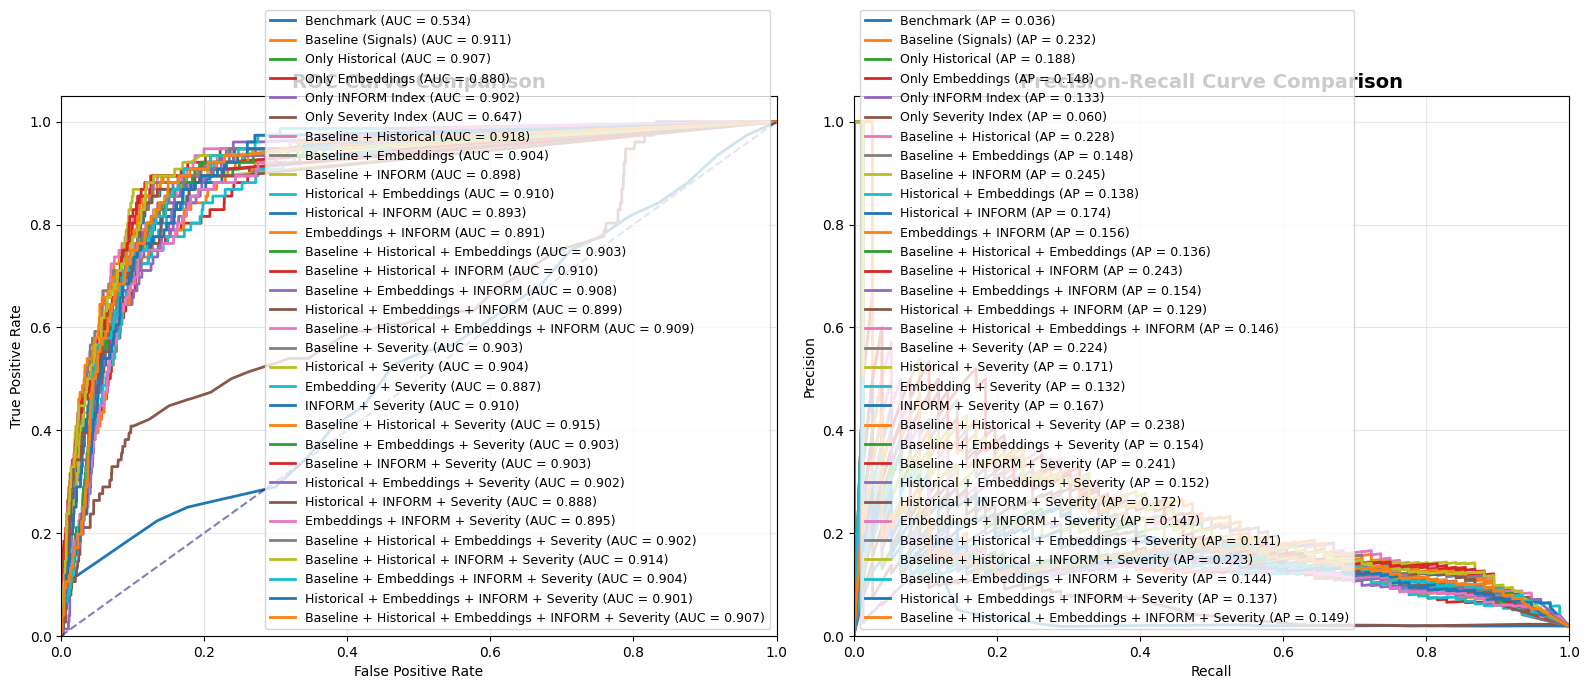

In [6]:
models_to_evaluate = [ "Benchmark",
          "Baseline (Signals)", "Only Historical","Only Embeddings", "Only INFORM Index", "Only Severity Index",
          "Baseline + Historical","Baseline + Embeddings", "Baseline + INFORM","Historical + Embeddings","Historical + INFORM",
          "Embeddings + INFORM","Baseline + Historical + Embeddings","Baseline + Historical + INFORM","Baseline + Embeddings + INFORM",
          "Historical + Embeddings + INFORM","Baseline + Historical + Embeddings + INFORM", "Baseline + Severity", "Historical + Severity", 
          "Embedding + Severity", "INFORM + Severity", "Baseline + Historical + Severity", "Baseline + Embeddings + Severity", 
          "Baseline + INFORM + Severity", "Historical + Embeddings + Severity", "Historical + INFORM + Severity", 
          "Embeddings + INFORM + Severity", "Baseline + Historical + Embeddings + Severity", "Baseline + Historical + INFORM + Severity", 
          "Baseline + Embeddings + INFORM + Severity", "Historical + Embeddings + INFORM + Severity", 
          "Baseline + Historical + Embeddings + INFORM + Severity",
]

evaluate_experiments(plots_filter=models_to_evaluate, threshold_05=False)


ANALYZING EXPERIMENT: Benchmark
🎯 Strategy: Minimizing Cost Function | Best Threshold Found: 0.946

--- TOP 10 PREDICTORS (Benchmark) ---
            feature  importance
allocation-eligible         1.0

Classification Report (Benchmark):
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      3984
         1.0       0.20      0.11      0.14        76

    accuracy                           0.98      4060
   macro avg       0.59      0.55      0.56      4060
weighted avg       0.97      0.98      0.97      4060


ANALYZING EXPERIMENT: Baseline (Signals) BEST
🎯 Strategy: Minimizing Cost Function | Best Threshold Found: 0.106

--- TOP 10 PREDICTORS (Baseline (Signals) BEST) ---
                 feature  importance
             disp_6m_avg    0.187288
          logfat_risk_12    0.152027
           logfat_risk_3    0.151780
                  risk_3    0.114523
rolling_3m_displacements    0.091903
                 risk_12    0.087683
        

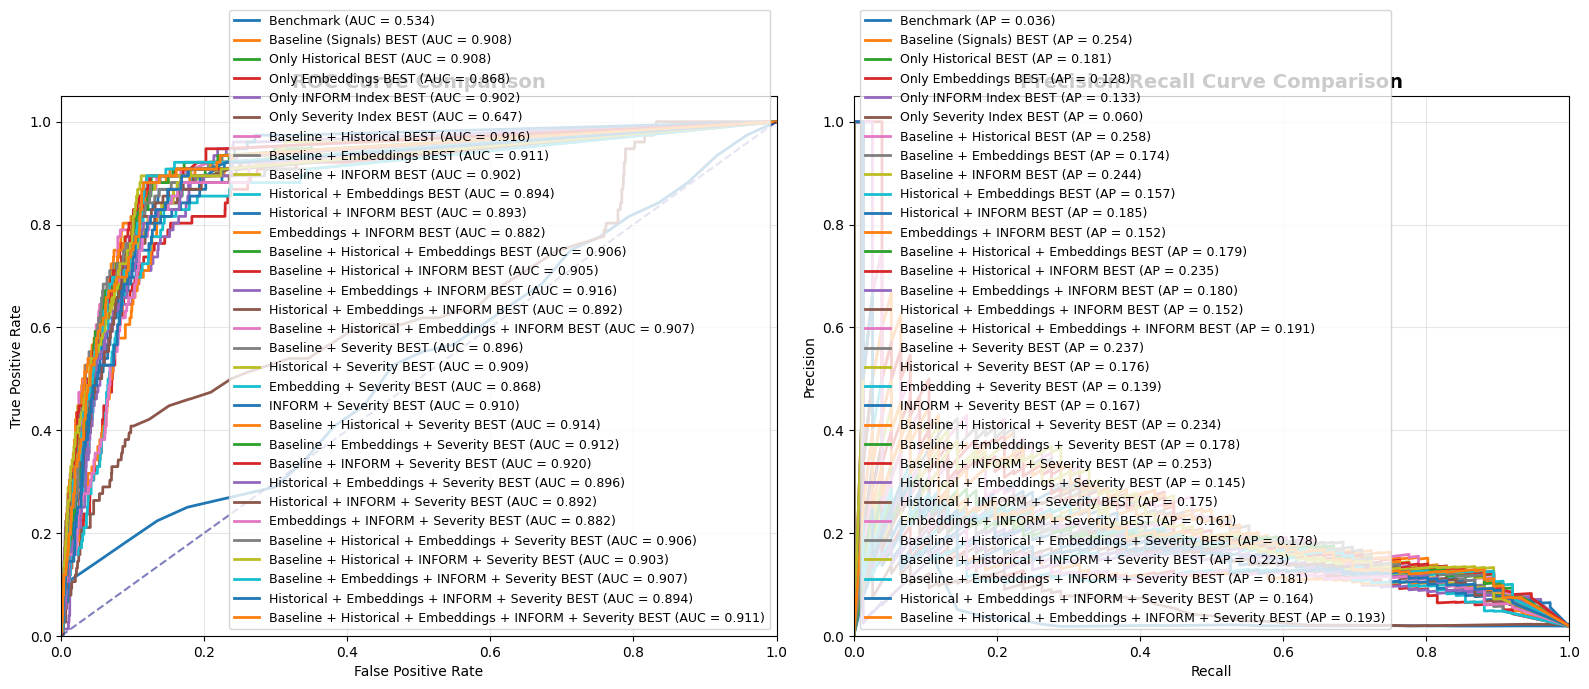

In [7]:
models_to_evaluate = [  "Benchmark","Baseline (Signals) BEST", "Only Historical BEST", "Only Embeddings BEST", "Only INFORM Index BEST", "Only Severity Index BEST",
          "Baseline + Historical BEST","Baseline + Embeddings BEST","Baseline + INFORM BEST","Historical + Embeddings BEST",
          "Historical + INFORM BEST","Embeddings + INFORM BEST","Baseline + Historical + Embeddings BEST",
          "Baseline + Historical + INFORM BEST","Baseline + Embeddings + INFORM BEST","Historical + Embeddings + INFORM BEST",
          "Baseline + Historical + Embeddings + INFORM BEST", "Baseline + Severity BEST", "Historical + Severity BEST", 
          "Embedding + Severity BEST", "INFORM + Severity BEST", "Baseline + Historical + Severity BEST", 
          "Baseline + Embeddings + Severity BEST", "Baseline + INFORM + Severity BEST", "Historical + Embeddings + Severity BEST", 
          "Historical + INFORM + Severity BEST", "Embeddings + INFORM + Severity BEST", 
          "Baseline + Historical + Embeddings + Severity BEST", "Baseline + Historical + INFORM + Severity BEST", 
          "Baseline + Embeddings + INFORM + Severity BEST", "Historical + Embeddings + INFORM + Severity BEST", 
          "Baseline + Historical + Embeddings + INFORM + Severity BEST",
]

evaluate_experiments(plots_filter=models_to_evaluate, threshold_05=False)

Now let's check what the errors are:

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score
df = pd.read_csv("../data_clean/final_data.csv")

In [9]:
def audit_model_errors(experiment_prefix, df_original, threshold=0.35, results_folder="results"):
    """
    Audits model predictions by matching clean regular columns with df_original.
    Perfect alignment tailored for standard DataFrames with RangeIndex.
    """
    # 1. Load raw prediction data from disk
    pred_file = os.path.join(results_folder, f"{experiment_prefix}_predictions.csv")
    df_preds = pd.read_csv(pred_file)
    
    # Apply the classification threshold to generate hard binary predictions
    df_preds['y_pred'] = (df_preds['y_prob'] >= threshold).astype(int)
    
    # 2. Extract only required business context columns from the original dataframe
    # No .reset_index() needed since 'month' and 'iso3' are already native columns
    df_status = df_original[['iso3', 'month', 'allocation-eligible']].copy()
    
    # --- HOMOGENEIZACIÓN DE FORMATOS ---
    # Convert dates to robust datetime objects and back to standardized YYYY-MM-DD strings
    df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce').dt.strftime('%Y-%m-%d')
    df_status['month'] = pd.to_datetime(df_status['month'], errors='coerce').dt.strftime('%Y-%m-%d')
    
    # Clean up string tokens for country codes
    df_preds['iso3'] = df_preds['iso3'].astype(str).str.strip().str.upper()
    df_status['iso3'] = df_status['iso3'].astype(str).str.strip().str.upper()

    # Merge predictions and truth states on our clear standard columns
    df_merged = pd.merge(df_preds, df_status, on=['iso3', 'month'], how='left')
    
    # --- COMPROBACIÓN DE CONTROL ---
    missing_matches = df_merged['allocation-eligible'].isna().sum()
    if missing_matches > 0:
        print(f"⚠️ DIAGNOSTIC WARNING: {missing_matches} rows failed to match out of {len(df_merged)}.")
        print(f"Preds Dates format sample: {df_preds['month'].iloc[0]}")
        print(f"Original df Dates format sample: {df_status['month'].iloc[0]}")
    else:
        print("✅ SUCCESS: 100% data alignment achieved! All scenarios successfully verified.")
    
    # Handle safe conversions and map types
    df_merged['allocation-eligible'] = df_merged['allocation-eligible'].fillna(0).astype(int)
    df_merged['y_true'] = df_merged['y_true'].astype(int)
    df_merged['y_pred'] = df_merged['y_pred'].astype(int)
    
    # 3. Classify every row into one of the 4 real-world operational scenarios
    conditions = [
        (df_merged['allocation-eligible'] == 0) & (df_merged['y_true'] == 1), # New crisis outbreak
        (df_merged['allocation-eligible'] == 1) & (df_merged['y_true'] == 1), # Ongoing crisis
        (df_merged['allocation-eligible'] == 0) & (df_merged['y_true'] == 0), # Continuous peace
        (df_merged['allocation-eligible'] == 1) & (df_merged['y_true'] == 0)  # De-escalation / Crisis ending
    ]
    labels = ['1. Hard Onset (New Crisis)', '2. Protracted (Continuation)', '3. Pure Peace', '4. Crisis Ending']
    df_merged['scenario'] = np.select(conditions, labels, default='Unknown')
    
    # 4. Map the model outcome into specific standard confusion matrix categories
    outcome_conditions = [
        (df_merged['y_true'] == 1) & (df_merged['y_pred'] == 1),
        (df_merged['y_true'] == 0) & (df_merged['y_pred'] == 0),
        (df_merged['y_true'] == 1) & (df_merged['y_pred'] == 0),
        (df_merged['y_true'] == 0) & (df_merged['y_pred'] == 1)
    ]
    outcome_labels = ['True Positive', 'True Negative', 'False Negative (CRITICAL)', 'False Positive (Warning)']
    df_merged['prediction_type'] = np.select(outcome_conditions, outcome_labels, default='Unknown')
    
    # 5. Print a comprehensive breakdown cross-tabulation table
    print(f"\n--- ERROR AUDIT REPORT: {experiment_prefix.upper()} ---")
    print(f"Classification threshold used: {threshold}")
    print("-" * 60)
    
    cross_tab = pd.crosstab(df_merged['scenario'], df_merged['prediction_type'], margins=True, margins_name="TOTAL")
    print(cross_tab)
    
    # 6. Calculate specific performance metric for Hard Onsets exclusively
    onsets = df_merged[df_merged['scenario'] == '1. Hard Onset (New Crisis)']
    if len(onsets) > 0:
        recall_onset = (onsets['prediction_type'] == 'True Positive').sum() / len(onsets)
        print(f"\n🚀 Success rate in HARD ONSETS (Recall): {recall_onset:.1%}")
    
    return df_merged

In [12]:
df_errors = audit_model_errors("baseline_historical_best", df, threshold=0.35)

# To isolate and inspect exactly which countries and months suffered critical misses:
critical_misses = df_errors[df_errors['prediction_type'] == 'False Negative (CRITICAL)']

✅ SUCCESS: 100% data alignment achieved! All scenarios successfully verified.

--- ERROR AUDIT REPORT: BASELINE_HISTORICAL_BEST ---
Classification threshold used: 0.35
------------------------------------------------------------
prediction_type               False Negative (CRITICAL)  \
scenario                                                  
1. Hard Onset (New Crisis)                           38   
2. Protracted (Continuation)                          0   
3. Pure Peace                                         0   
4. Crisis Ending                                      0   
TOTAL                                                38   

prediction_type               False Positive (Warning)  True Negative  \
scenario                                                                
1. Hard Onset (New Crisis)                           0              0   
2. Protracted (Continuation)                         0              0   
3. Pure Peace                                       72           